## Hyperparameter Tuning for KNN

### Subtask:
Utilize GridSearchCV from sklearn.model_selection to perform hyperparameter tuning for the KNeighborsClassifier. Define a parameter grid that includes different values for n_neighbors (e.g., 3, 5, 7, 9, 11) and different distance metrics (e.g., 'euclidean', 'manhattan'). Fit GridSearchCV to the scaled training data (X_train_scaled, y_train_knn) to find the optimal set of hyperparameters.


**Reasoning**:
The subtask requires performing hyperparameter tuning for the `KNeighborsClassifier` using `GridSearchCV`. This involves defining a parameter grid, initializing `GridSearchCV`, fitting it to the scaled training data, and then reporting the best parameters and score.



In [13]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Loading digits dataset...")
X, y = load_digits(return_X_y=True)

print("Splitting data into training and validation sets...")
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Data preparation complete.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_val_scaled shape: {X_val_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")

Loading digits dataset...
Splitting data into training and validation sets...
Scaling features...
Data preparation complete.
X_train_scaled shape: (1437, 64)
X_val_scaled shape: (360, 64)
y_train shape: (1437,)
y_val shape: (360,)


Starting hyperparameter tuning for KNN using GridSearchCV...
Fitting GridSearchCV to X_train_scaled and y_train_knn...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Hyperparameter tuning complete.
Best parameters found: {'metric': 'euclidean', 'n_neighbors': 3}
Best cross-validation score: 0.9749
Making predictions on validation data...

--- Classification Report (Tuned KNN) ---
              precision    recall  f1-score   support

     Class 0       0.97      1.00      0.98        94
     Class 1       0.98      0.98      0.98       127
     Class 2       0.99      0.97      0.98       139

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360


--- Confusion Matrix (Tuned KNN) ---


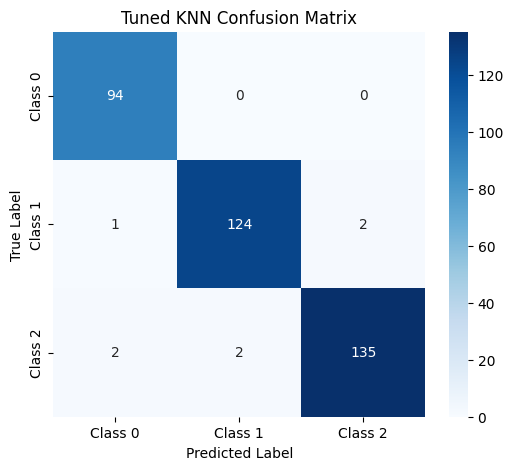

Calculating accuracy for different K values...


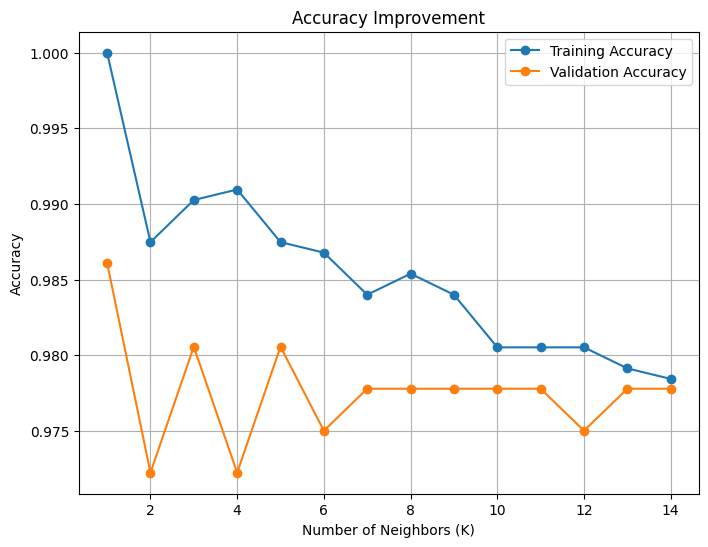

In [17]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("Starting hyperparameter tuning for KNN using GridSearchCV...")

# -------- Convert labels into 3 classes --------
# 0–3 -> Class 0, 4–6 -> Class 1, 7–9 -> Class 2
y_train_knn = np.digitize(y_train, bins=[3,6])
y_val_knn = np.digitize(y_val, bins=[3,6])

# -------- Parameter grid --------
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13],
    'metric': ['euclidean']
}

# -------- Model --------
knn = KNeighborsClassifier()

grid_search = GridSearchCV(
    knn,
    param_grid,
    cv=3,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

print("Fitting GridSearchCV to X_train_scaled and y_train_knn...")
grid_search.fit(X_train_scaled, y_train_knn)

print("\nHyperparameter tuning complete.")

print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Best model
best_knn_model = grid_search.best_estimator_

print("Making predictions on validation data...")
y_pred_tuned_knn = best_knn_model.predict(X_val_scaled)

# -------- Class labels (3 classes) --------
class_labels = ['Class 0', 'Class 1', 'Class 2']

print("\n--- Classification Report (Tuned KNN) ---")
print(classification_report(y_val_knn, y_pred_tuned_knn, target_names=class_labels))

print("\n--- Confusion Matrix (Tuned KNN) ---")

cm_tuned_knn = confusion_matrix(y_val_knn, y_pred_tuned_knn)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_tuned_knn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title('Tuned KNN Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


# -------- Accuracy improvement graph --------

k_values = range(1, 15)

train_accuracy = []
val_accuracy = []

print("Calculating accuracy for different K values...")

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')

    knn.fit(X_train_scaled, y_train_knn)

    y_train_pred = knn.predict(X_train_scaled)
    y_val_pred = knn.predict(X_val_scaled)

    train_acc = accuracy_score(y_train_knn, y_train_pred)
    val_acc = accuracy_score(y_val_knn, y_val_pred)

    train_accuracy.append(train_acc)
    val_accuracy.append(val_acc)

# Plot graph
plt.figure(figsize=(8,6))

plt.plot(k_values, train_accuracy, marker='o', label='Training Accuracy')
plt.plot(k_values, val_accuracy, marker='o', label='Validation Accuracy')

plt.title("Accuracy Improvement")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [15]:
best_k = k_values[val_accuracy.index(max(val_accuracy))]
print("Best K value:", best_k)

Best K value: 1
